In [29]:
from faker import Faker
import pandas as pd
import random

In [2]:
pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 398.4 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 398.4 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 398.4 kB/s eta 0:00:04
   ---------- ----------------------------- 0.5/2.0 MB 398.4 kB/s eta 0:00:04
   --------------- ------------------------ 0.8/2.0 MB 349.9 kB/s eta 0:00:04
   --------------- ------------------------ 0.8/2.0 MB 349.9 kB/s eta 0:00:04
   --------------- ------------------------ 0.8/2

In [30]:
fake = Faker("es_MX")

In [31]:
#Generamos datos
datos = []
for i in range(100):
    datos.append({
        "id_usuario": i +1,
        "nombre": fake.name(),
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100,50000),
        "plataforma": random.choice(
            ["Tiktok","Instagram", "Youtube"]
        )
    })

In [32]:
df = pd.DataFrame(datos)
df.head()

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Lucas Alejandro Centeno Saucedo,eloisa14@example.org,25,13790,Instagram
1,2,Mario Jaime Soria,eugenio13@example.com,34,22021,Instagram
2,3,Mariano Villanueva,augustochacon@example.com,59,12861,Tiktok
3,4,Daniela Aguilera,granadonoemi@example.org,59,33813,Instagram
4,5,Estela Páez Gamboa,xvaldivia@example.com,22,1531,Instagram


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [34]:
df.describe(include = "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.000000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Lucas Alejandro Centeno Saucedo,eloisa14@example.org,NaN,NaN,Instagram
freq,NaN,1,1,NaN,NaN,40
mean,50.500000,NaN,NaN,43.160000,23197.890000,NaN
std,29.011492,NaN,NaN,12.725319,14348.549133,NaN
min,1.000000,NaN,NaN,19.000000,945.000000,NaN
25%,25.750000,NaN,NaN,32.000000,12838.750000,NaN
50%,50.500000,NaN,NaN,44.000000,21650.500000,NaN
75%,75.250000,NaN,NaN,52.500000,36214.750000,NaN


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

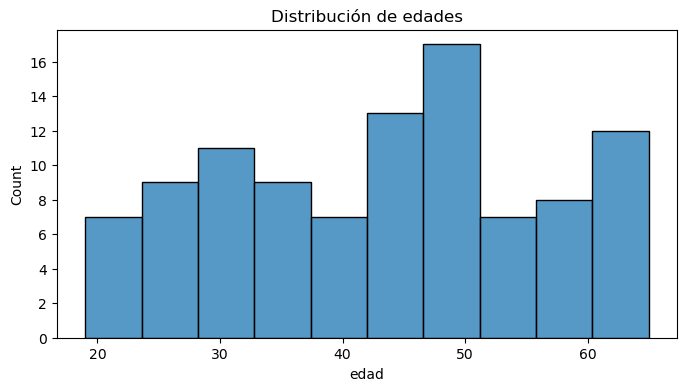

In [36]:
#Distribucion de edades
plt.figure(figsize= (8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

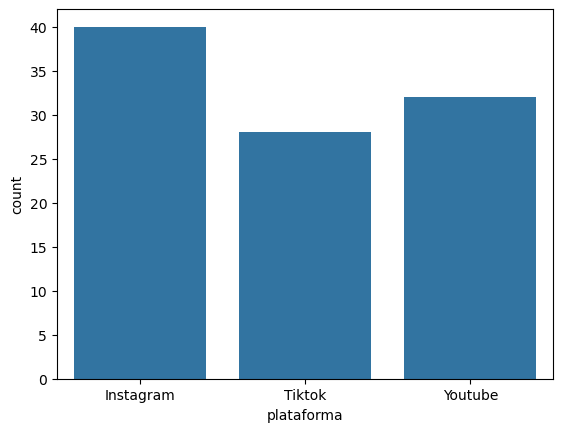

In [37]:
#Usuarios por plataforma
sns.countplot(
    x="plataforma",
    data=df
)
plt.show()

In [38]:
#Generamos una copia
df_sucio = df.copy()

In [39]:
#Le colocamos valores nulos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "nombre"] = None

In [40]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [41]:
#edades invalidas
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [42]:
df_sucio.describe()["edad"]

count    100.000000
mean      40.330000
std       17.018145
min      -10.000000
25%       31.000000
50%       43.000000
75%       51.250000
max       65.000000
Name: edad, dtype: float64

In [43]:
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "seguidores"] = 5000000

In [44]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.718863e+05
std      1.090255e+06
min      9.450000e+02
25%      1.331850e+04
50%      2.235000e+04
75%      3.782975e+04
max      5.000000e+06
Name: seguidores, dtype: float64

In [45]:
#Generamos correo invalidos
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [47]:
df_sucio.describe(include=["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Lucas Alejandro Centeno Saucedo,correo_invalido,Instagram
freq,1,5,40


In [49]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [51]:
pd.set_option("display.float_format", lambda x: "{:.2f}".format(x))

In [52]:
df_sucio.describe(include= "all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.00,95,100,100.00,100.00,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Lucas Alejandro Centeno Saucedo,correo_invalido,NaN,NaN,Instagram
freq,NaN,1,5,NaN,NaN,40
mean,50.50,NaN,NaN,40.33,271886.34,NaN
std,29.01,NaN,NaN,17.02,1090255.14,NaN
min,1.00,NaN,NaN,-10.00,945.00,NaN
25%,25.75,NaN,NaN,31.00,13318.50,NaN
50%,50.50,NaN,NaN,43.00,22350.00,NaN
75%,75.25,NaN,NaN,51.25,37829.75,NaN
